Part-1


Architecture: [2, 8, 1]
Activation: sigmoid
Optimizer: sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6072266655451632
Val Loss: 0.5687782205669887
Test Loss: 0.5757949601824894


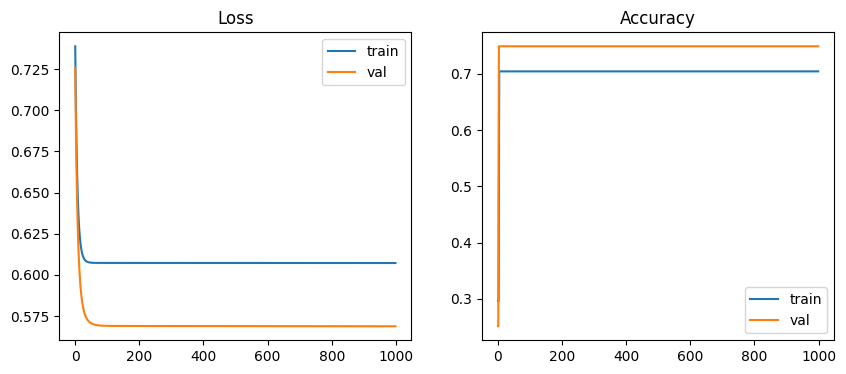


Architecture: [2, 8, 1]
Activation: sigmoid
Optimizer: momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6065792093962005
Val Loss: 0.5678521243608508
Test Loss: 0.5755110942356464


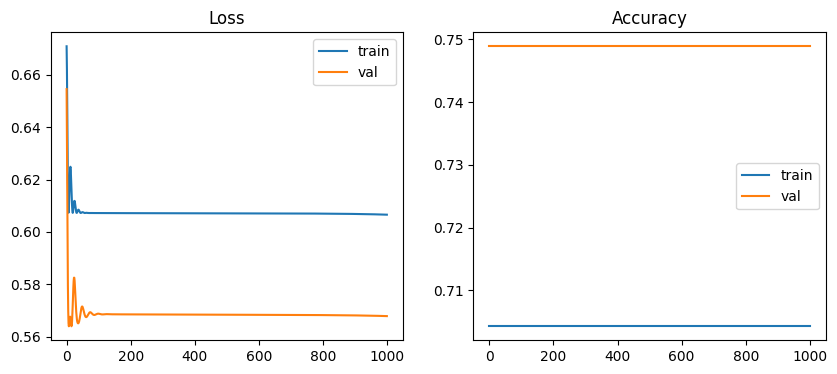


Architecture: [2, 8, 1]
Activation: relu
Optimizer: sgd
Train Acc: 0.9414285714285714
Val Acc: 0.9555555555555556
Test Acc: 0.9488888888888889
Train Loss: 0.19364613342346101
Val Loss: 0.17210064796782037
Test Loss: 0.18463442198097937


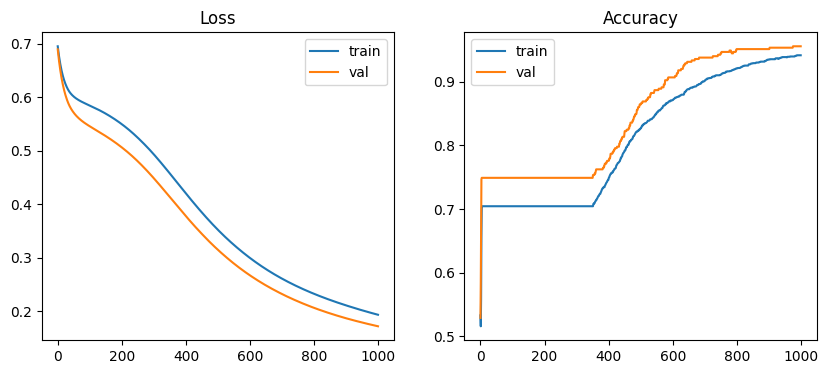


Architecture: [2, 8, 1]
Activation: relu
Optimizer: momentum
Train Acc: 0.9876190476190476
Val Acc: 0.9888888888888889
Test Acc: 0.9911111111111112
Train Loss: 0.05209104176506709
Val Loss: 0.048108013733299135
Test Loss: 0.05382232416105034


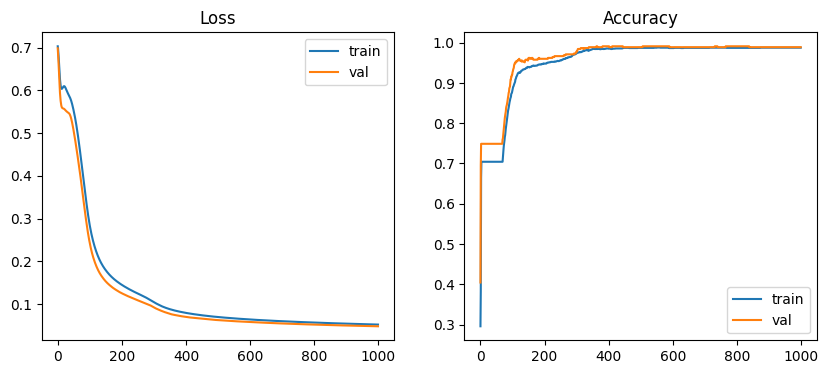


Architecture: [2, 8, 8, 8, 8, 1]
Activation: sigmoid
Optimizer: sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.607189171963272
Val Loss: 0.5684829946348268
Test Loss: 0.5761966015899185


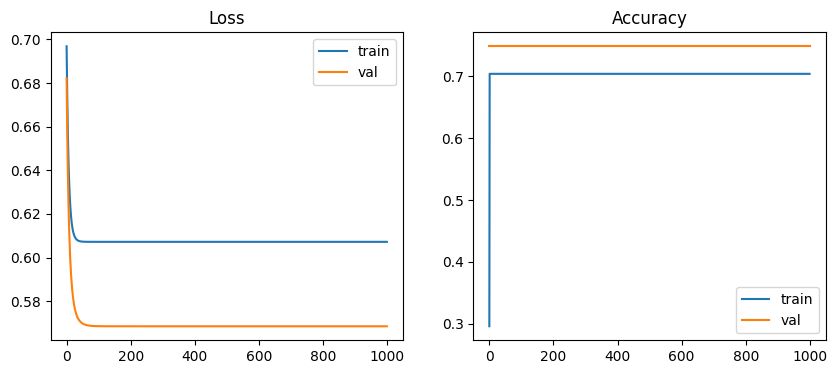


Architecture: [2, 8, 8, 8, 8, 1]
Activation: sigmoid
Optimizer: momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071891799657235
Val Loss: 0.5684829288412124
Test Loss: 0.5761967648922488


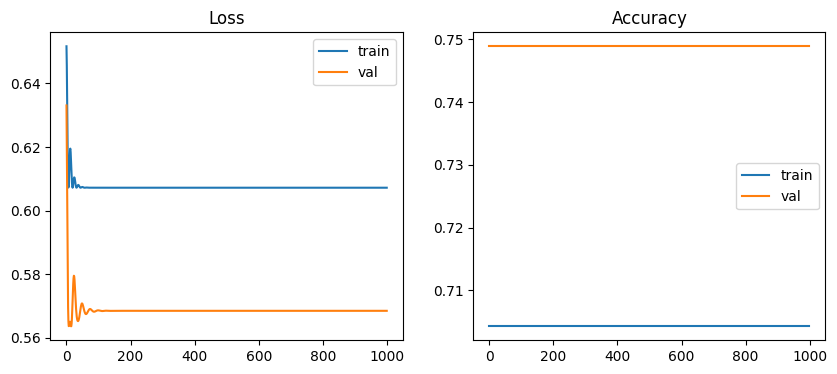


Architecture: [2, 8, 8, 8, 8, 1]
Activation: relu
Optimizer: sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071343643084588
Val Loss: 0.5684249677390558
Test Loss: 0.5761405867116519


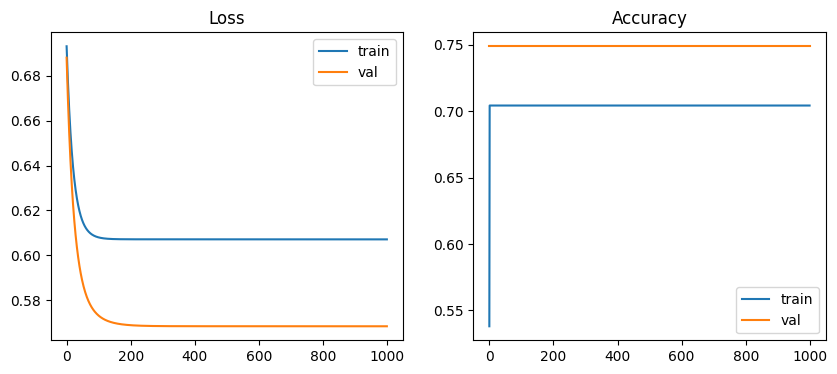


Architecture: [2, 8, 8, 8, 8, 1]
Activation: relu
Optimizer: momentum
Train Acc: 0.9971428571428571
Val Acc: 0.9933333333333333
Test Acc: 0.9911111111111112
Train Loss: 0.010264227619907945
Val Loss: 0.012726563577783713
Test Loss: 0.015772402231709715


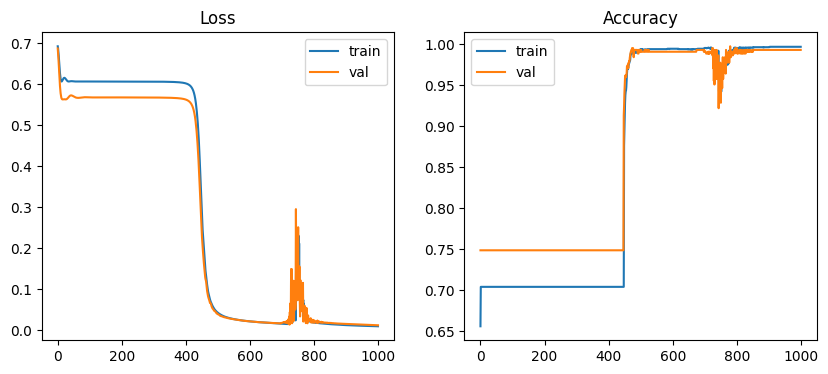


Architecture: [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1]
Activation: sigmoid
Optimizer: sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071891736019922
Val Loss: 0.5684829677289849
Test Loss: 0.5761966600031454


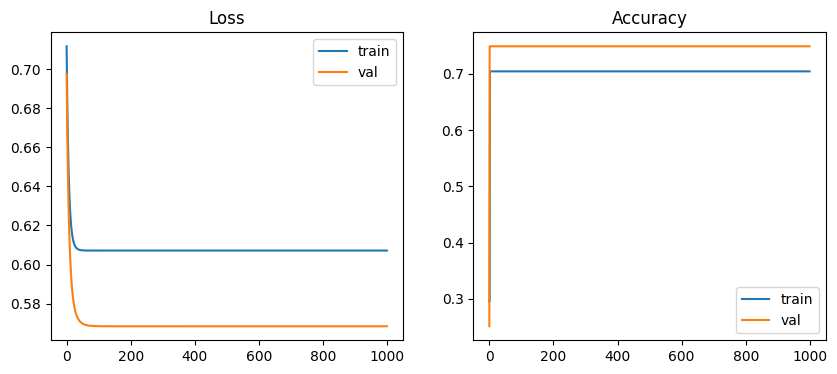


Architecture: [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1]
Activation: sigmoid
Optimizer: momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071891736020102
Val Loss: 0.5684829677292794
Test Loss: 0.5761966600027681


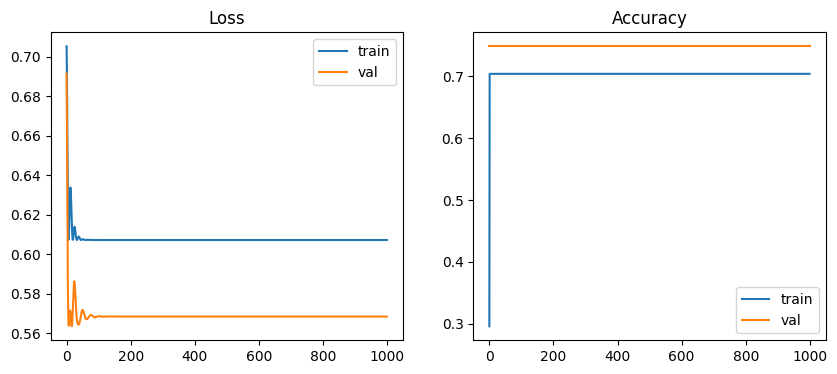


Architecture: [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1]
Activation: relu
Optimizer: sgd
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071891721789419
Val Loss: 0.5684829661539961
Test Loss: 0.5761966585171374


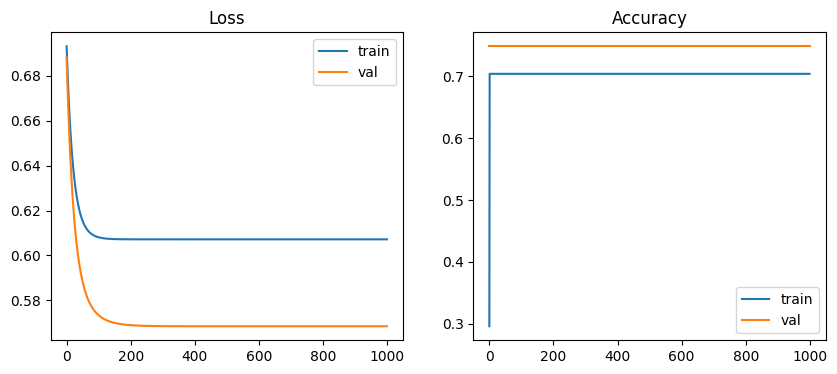


Architecture: [2, 8, 8, 8, 8, 8, 8, 8, 8, 8, 1]
Activation: relu
Optimizer: momentum
Train Acc: 0.7042857142857143
Val Acc: 0.7488888888888889
Test Acc: 0.74
Train Loss: 0.6071891726690112
Val Loss: 0.5684829665526396
Test Loss: 0.5761966590037092


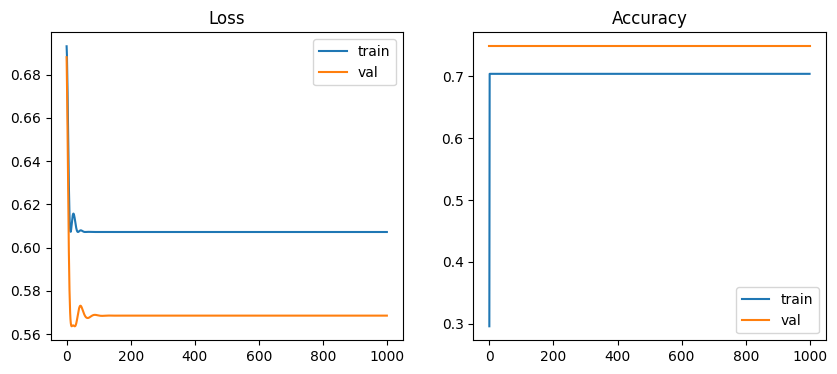

In [6]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 3000
x1 = np.random.uniform(-2,2,N)
x2 = np.random.uniform(-2,2,N)

X = np.stack([x1,x2],axis=1)

y = ((x1**2 + x2**2) > 1.5).astype(float).reshape(-1,1)

idx = np.random.permutation(N)
X = X[idx]
y = y[idx]

train_end = int(0.7*N)
val_end = int(0.85*N)

X_train,X_val,X_test = X[:train_end],X[train_end:val_end],X[val_end:]
y_train,y_val,y_test = y[:train_end],y[train_end:val_end],y[val_end:]

def sigmoid(z):
    return 1/(1+np.exp(-z))

def relu(z):
    return np.maximum(0,z)

def sigmoid_deriv(a):
    return a*(1-a)

def relu_deriv(z):
    return (z>0).astype(float)

def bce_loss(y,yhat):
    eps=1e-8
    yhat=np.clip(yhat,eps,1-eps)
    return -np.mean(y*np.log(yhat)+(1-y)*np.log(1-yhat))

def accuracy(y,yhat):
    ybin=(yhat>=0.5).astype(int)
    return np.mean(ybin==y)

def init_network(layer_sizes):

    params={}
    L=len(layer_sizes)-1

    for l in range(1,L+1):

        params["W"+str(l)] = np.random.randn(layer_sizes[l-1],layer_sizes[l])*0.1
        params["b"+str(l)] = np.zeros((1,layer_sizes[l]))

    return params


def forward(X,params,activation):

    cache={}
    A=X
    cache["A0"]=X
    L=len(params)//2

    for l in range(1,L):

        Z=A@params["W"+str(l)] + params["b"+str(l)]

        if activation=="sigmoid":
            A=sigmoid(Z)
        else:
            A=relu(Z)

        cache["Z"+str(l)]=Z
        cache["A"+str(l)]=A

    Z=A@params["W"+str(L)] + params["b"+str(L)]
    A=sigmoid(Z)

    cache["Z"+str(L)]=Z
    cache["A"+str(L)]=A

    return A,cache


def backward(params,cache,y,activation):

    grads={}
    L=len(params)//2
    m=y.shape[0]

    A=cache["A"+str(L)]
    dZ=A-y

    for l in reversed(range(1,L+1)):

        A_prev=cache["A"+str(l-1)]

        grads["dW"+str(l)] = (A_prev.T@dZ)/m
        grads["db"+str(l)] = np.sum(dZ,axis=0,keepdims=True)/m

        if l>1:

            dA=dZ@params["W"+str(l)].T
            Z=cache["Z"+str(l-1)]

            if activation=="sigmoid":
                dZ=dA*sigmoid_deriv(cache["A"+str(l-1)])
            else:
                dZ=dA*relu_deriv(Z)

    return grads


def update_sgd(params,grads,lr):

    L=len(params)//2

    for l in range(1,L+1):

        params["W"+str(l)]-=lr*grads["dW"+str(l)]
        params["b"+str(l)]-=lr*grads["db"+str(l)]

    return params

def update_momentum(params,grads,vel,lr,beta=0.9):

    L=len(params)//2

    for l in range(1,L+1):

        vel["dW"+str(l)] = beta*vel["dW"+str(l)] + lr*grads["dW"+str(l)]
        vel["db"+str(l)] = beta*vel["db"+str(l)] + lr*grads["db"+str(l)]

        params["W"+str(l)] -= vel["dW"+str(l)]
        params["b"+str(l)] -= vel["db"+str(l)]

    return params,vel


def train_model(layer_sizes,activation,optimizer,epochs=1000,lr=0.1):

    params=init_network(layer_sizes)

    L=len(params)//2

    vel={}
    if optimizer=="momentum":
        for l in range(1,L+1):
            vel["dW"+str(l)] = np.zeros_like(params["W"+str(l)])
            vel["db"+str(l)] = np.zeros_like(params["b"+str(l)])

    train_loss=[]
    val_loss=[]
    train_acc=[]
    val_acc=[]

    for e in range(epochs):

        yhat,cache=forward(X_train,params,activation)

        loss=bce_loss(y_train,yhat)
        grads=backward(params,cache,y_train,activation)

        if optimizer=="sgd":
            params=update_sgd(params,grads,lr)
        else:
            params,vel=update_momentum(params,grads,vel,lr)

        val_pred,_=forward(X_val,params,activation)

        train_loss.append(loss)
        val_loss.append(bce_loss(y_val,val_pred))
        train_acc.append(accuracy(y_train,yhat))
        val_acc.append(accuracy(y_val,val_pred))

    test_pred,_=forward(X_test,params,activation)

    print("\nArchitecture:",layer_sizes)
    print("Activation:",activation)
    print("Optimizer:",optimizer)

    print("Train Acc:",accuracy(y_train,yhat))
    print("Val Acc:",accuracy(y_val,val_pred))
    print("Test Acc:",accuracy(y_test,test_pred))

    print("Train Loss:",bce_loss(y_train,yhat))
    print("Val Loss:",bce_loss(y_val,val_pred))
    print("Test Loss:",bce_loss(y_test,test_pred))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(train_loss,label="train")
    plt.plot(val_loss,label="val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_acc,label="train")
    plt.plot(val_acc,label="val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()


architectures = [
    [2,8,1],
    [2,8,8,8,8,1],
    [2,8,8,8,8,8,8,8,8,8,1]
]

activations=["sigmoid","relu"]
optimizers=["sgd","momentum"]


for arch in architectures:
    for act in activations:
        for opt in optimizers:
            train_model(arch,act,opt)

Part-2

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

np.random.seed(0)

digits=load_digits()
X=digits.images
y=digits.target
mask=(y==0)|(y==1)
X=X[mask]
y=y[mask].reshape(-1,1)
X=X/16.0

n=len(X)
idx=np.random.permutation(n)
t1=int(0.7*n)
t2=int(0.85*n)

X_train,X_val,X_test=X[idx[:t1]],X[idx[t1:t2]],X[idx[t2:]]
y_train,y_val,y_test=y[idx[:t1]],y[idx[t1:t2]],y[idx[t2:]]

def sigmoid(x): return 1/(1+np.exp(-x))
def relu(x): return np.maximum(0,x)
def drelu(x): return (x>0).astype(float)

def bce(y,yh):
    yh=np.clip(yh,1e-8,1-1e-8)
    return -np.mean(y*np.log(yh)+(1-y)*np.log(1-yh))

def acc(y,yh): return np.mean((yh>0.5)==y)

class Dense:
    def __init__(self,inp,h):
        self.W1=np.random.randn(inp,h)*0.1
        self.b1=np.zeros((1,h))
        self.W2=np.random.randn(h,1)*0.1
        self.b2=np.zeros((1,1))
    def forward(self,X):
        self.X=X
        self.Z1=X@self.W1+self.b1
        self.A1=relu(self.Z1)
        self.Z2=self.A1@self.W2+self.b2
        self.A2=sigmoid(self.Z2)
        return self.A2
    def backward(self,y,lr):
        m=y.shape[0]
        dZ2=self.A2-y
        dW2=self.A1.T@dZ2/m
        db2=np.sum(dZ2,0,keepdims=True)/m
        dA1=dZ2@self.W2.T
        dZ1=dA1*drelu(self.Z1)
        dW1=self.X.T@dZ1/m
        db1=np.sum(dZ1,0,keepdims=True)/m
        self.W2-=lr*dW2
        self.b2-=lr*db2
        self.W1-=lr*dW1
        self.b1-=lr*db1

def conv_forward(X,W,b):
    n,h,w=X.shape
    f,kh,kw=W.shape
    oh=h-kh+1
    ow=w-kw+1
    out=np.zeros((n,f,oh,ow))
    for i in range(n):
        for j in range(f):
            for y1 in range(oh):
                for x1 in range(ow):
                    out[i,j,y1,x1]=np.sum(X[i,y1:y1+kh,x1:x1+kw]*W[j])+b[j]
    return out

def conv_backward(X,W,dout):
    n,h,w=X.shape
    f,kh,kw=W.shape
    oh,ow=dout.shape[2],dout.shape[3]
    dW=np.zeros_like(W)
    db=np.zeros((f,1))
    dX=np.zeros_like(X)
    for i in range(n):
        for j in range(f):
            for y1 in range(oh):
                for x1 in range(ow):
                    region=X[i,y1:y1+kh,x1:x1+kw]
                    dW[j]+=dout[i,j,y1,x1]*region
                    db[j]+=dout[i,j,y1,x1]
                    dX[i,y1:y1+kh,x1:x1+kw]+=dout[i,j,y1,x1]*W[j]
    return dX,dW,db

def maxpool(X):
    n,c,h,w=X.shape
    out=np.zeros((n,c,h//2,w//2))
    mask=np.zeros_like(X)
    for i in range(n):
        for j in range(c):
            for y1 in range(0,h,2):
                for x1 in range(0,w,2):
                    patch=X[i,j,y1:y1+2,x1:x1+2]
                    m=np.max(patch)
                    out[i,j,y1//2,x1//2]=m
                    ind=np.unravel_index(np.argmax(patch),(2,2))
                    mask[i,j,y1+ind[0],x1+ind[1]]=1
    return out,mask

def maxpool_back(dout,mask):
    n,c,h,w=mask.shape
    dX=np.zeros_like(mask)
    for i in range(n):
        for j in range(c):
            for y1 in range(h//2):
                for x1 in range(w//2):
                    dX[i,j,2*y1:2*y1+2,2*x1:2*x1+2]+=mask[i,j,2*y1:2*y1+2,2*x1:2*x1+2]*dout[i,j,y1,x1]
    return dX

class CNN:
    def __init__(self,pool=True,drop=0.0):
        self.pool=pool
        self.drop=drop
        self.Wc=np.random.randn(4,3,3)*0.1
        self.bc=np.zeros((4,1))
        self.Wd=np.random.randn(4*3*3 if pool else 4*6*6,1)*0.1
        self.bd=np.zeros((1,1))
    def forward(self,X,train=True):
        self.X=X
        self.Z=conv_forward(X,self.Wc,self.bc)
        self.A=relu(self.Z)
        if self.pool:
            self.P,self.mask=maxpool(self.A)
        else:
            self.P=self.A
        self.F=self.P.reshape(len(X),-1)
        if train and self.drop>0:
            self.D=(np.random.rand(*self.F.shape)>self.drop).astype(float)
            self.F=self.F*self.D
        else:
            self.D=None
        self.Z2=self.F@self.Wd+self.bd
        self.A2=sigmoid(self.Z2)
        return self.A2
    def backward(self,y,lr):
        m=y.shape[0]
        dZ2=self.A2-y
        dWd=self.F.T@dZ2/m
        dbd=np.sum(dZ2,0,keepdims=True)/m
        dF=dZ2@self.Wd.T
        if self.D is not None:
            dF=dF*self.D
        dP=dF.reshape(self.P.shape)
        if self.pool:
            dA=maxpool_back(dP,self.mask)
        else:
            dA=dP
        dZ=dA*drelu(self.Z)
        dX,dWc,dbc=conv_backward(self.X,self.Wc,dZ)
        self.Wd-=lr*dWd
        self.bd-=lr*dbd
        self.Wc-=lr*dWc
        self.bc-=lr*dbc

Xd_train=X_train.reshape(len(X_train),-1)
Xd_val=X_val.reshape(len(X_val),-1)
Xd_test=X_test.reshape(len(X_test),-1)

dense=Dense(64,32)

for e in range(50):
    yh=dense.forward(Xd_train)
    dense.backward(y_train,0.1)

yh_train=dense.forward(Xd_train)
yh_val=dense.forward(Xd_val)
yh_test=dense.forward(Xd_test)

print("Dense",acc(y_train,yh_train),acc(y_val,yh_val),acc(y_test,yh_test),bce(y_test,yh_test))

configs=[("pool",True,0.0),("nopool",False,0.0),("dropout",True,0.5),("nodrop",True,0.0)]

for name,pool,drop in configs:
    model=CNN(pool,drop)
    for e in range(20):
        yh=model.forward(X_train)
        model.backward(y_train,0.01)
    yh_train=model.forward(X_train,False)
    yh_val=model.forward(X_val,False)
    yh_test=model.forward(X_test,False)
    print(name,acc(y_train,yh_train),acc(y_val,yh_val),acc(y_test,yh_test),bce(y_test,yh_test))

Dense 1.0 1.0 1.0 0.0828019253197617


/tmp/ipykernel_1338/646768333.py:70: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  out[i,j,y1,x1]=np.sum(X[i,y1:y1+kh,x1:x1+kw]*W[j])+b[j]


pool 0.9920318725099602 0.9818181818181818 0.9814814814814815 0.1826153654705585
nopool 0.9760956175298805 0.9818181818181818 1.0 0.07342047375262353
dropout 0.9123505976095617 0.8909090909090909 0.9259259259259259 0.40794390909563477
nodrop 0.9840637450199203 0.9636363636363636 0.9814814814814815 0.2054280151763194


Part-3


Optimizer: sgd
Train Acc: 0.5976095617529881
Val Acc: 0.5818181818181818
Test Acc: 0.6296296296296297
Train Loss: 0.6823031870039005
Val Loss: 0.6850026503368923
Test Loss: 0.6802021793203522


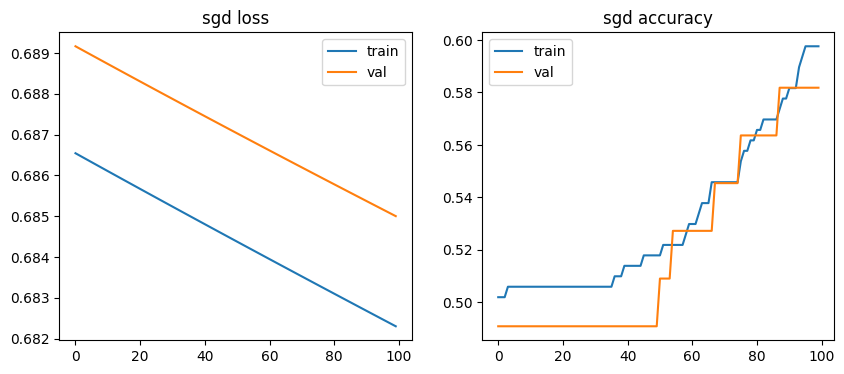


Optimizer: momentum
Train Acc: 0.9163346613545816
Val Acc: 0.8909090909090909
Test Acc: 0.9074074074074074
Train Loss: 0.6611963413069999
Val Loss: 0.6602931420450907
Test Loss: 0.6611909106872069


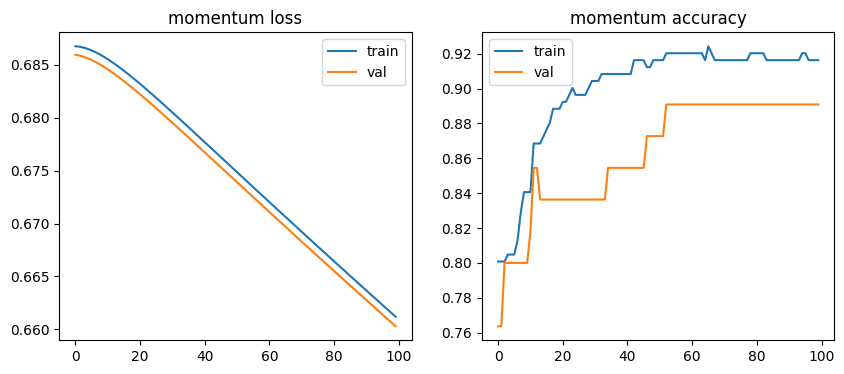


Optimizer: adam
Train Acc: 0.9880478087649402
Val Acc: 0.9818181818181818
Test Acc: 1.0
Train Loss: 0.35173546357334823
Val Loss: 0.35449519725039064
Test Loss: 0.34585024252986013


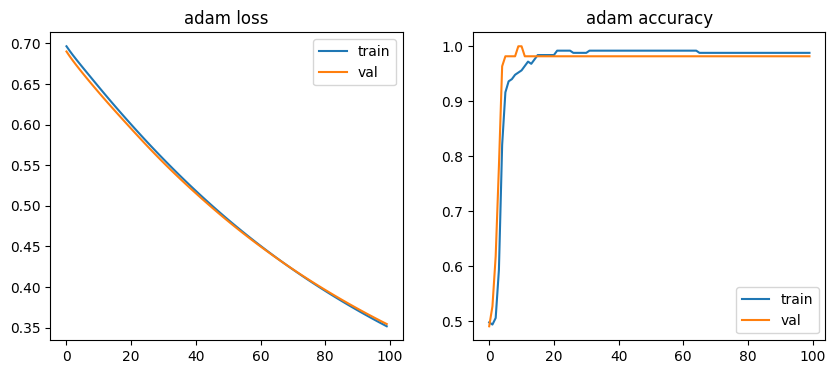

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


def sigmoid(x):
    return 1/(1+np.exp(-x))

def relu(x):
    return np.maximum(0,x)

def relu_deriv(x):
    return (x>0).astype(float)

def bce_loss(y,yhat):
    eps=1e-8
    yhat=np.clip(yhat,eps,1-eps)
    return -np.mean(y*np.log(yhat)+(1-y)*np.log(1-yhat))

def accuracy(y,yhat):
    ybin=(yhat>=0.5).astype(int)
    return np.mean(ybin==y)


def conv_forward(X,K,b):

    N,H,W = X.shape
    F,F2,Cout = K.shape

    out_h = H-F+1
    out_w = W-F+1

    out=np.zeros((N,out_h,out_w,Cout))

    for n in range(N):
        for c in range(Cout):
            for i in range(out_h):
                for j in range(out_w):

                    region=X[n,i:i+F,j:j+F]
                    out[n,i,j,c]=np.sum(region*K[:,:,c])+b[c]

    return out

def maxpool(X):

    N,H,W,C = X.shape
    out=np.zeros((N,H//2,W//2,C))

    for n in range(N):
        for c in range(C):
            for i in range(0,H,2):
                for j in range(0,W,2):

                    region=X[n,i:i+2,j:j+2,c]
                    out[n,i//2,j//2,c]=np.max(region)

    return out


def flatten(X):
    return X.reshape(X.shape[0],-1)


def cnn_forward(X,params):

    K=params["K"]
    b=params["b"]
    W=params["W"]
    b2=params["b2"]

    Z1=conv_forward(X,K,b)
    A1=relu(Z1)

    P=maxpool(A1)

    F=flatten(P)

    Z2=F@W + b2
    A2=sigmoid(Z2)

    cache=(Z1,A1,P,F)

    return A2,cache


def cnn_backward(X,y,yhat,cache,params):

    Z1,A1,P,F=cache
    W=params["W"]

    m=y.shape[0]

    dZ2=yhat-y
    dW=(F.T@dZ2)/m
    db2=np.sum(dZ2,axis=0,keepdims=True)/m

    grads={"dW":dW,"db2":db2}

    return grads


def update_sgd(params,grads,lr):

    params["W"]-=lr*grads["dW"]
    params["b2"]-=lr*grads["db2"]

    return params

def update_momentum(params,grads,vel,lr,beta=0.9):

    vel["dW"]=beta*vel["dW"]+lr*grads["dW"]
    vel["db2"]=beta*vel["db2"]+lr*grads["db2"]

    params["W"]-=vel["dW"]
    params["b2"]-=vel["db2"]

    return params,vel

def update_adam(params,grads,adam,lr,t,b1=0.9,b2=0.999,eps=1e-8):

    adam["mW"]=b1*adam["mW"]+(1-b1)*grads["dW"]
    adam["vW"]=b2*adam["vW"]+(1-b2)*(grads["dW"]**2)

    mhat=adam["mW"]/(1-b1**t)
    vhat=adam["vW"]/(1-b2**t)

    params["W"]-=lr*mhat/(np.sqrt(vhat)+eps)

    adam["mb"]=b1*adam["mb"]+(1-b1)*grads["db2"]
    adam["vb"]=b2*adam["vb"]+(1-b2)*(grads["db2"]**2)

    mhat=adam["mb"]/(1-b1**t)
    vhat=adam["vb"]/(1-b2**t)

    params["b2"]-=lr*mhat/(np.sqrt(vhat)+eps)

    return params,adam


def train_optimizer(X_train,y_train,X_val,y_val,X_test,y_test,optimizer):

    K=np.random.randn(3,3,4)*0.1
    b=np.zeros(4)

    W=np.random.randn(3*3*4,1)*0.1
    b2=np.zeros((1,1))

    params={"K":K,"b":b,"W":W,"b2":b2}

    vel={"dW":np.zeros_like(W),"db2":np.zeros_like(b2)}
    adam={
        "mW":np.zeros_like(W),
        "vW":np.zeros_like(W),
        "mb":np.zeros_like(b2),
        "vb":np.zeros_like(b2)
    }

    train_loss=[]
    val_loss=[]
    train_acc=[]
    val_acc=[]

    lr=0.01
    epochs=100

    for t in range(1,epochs+1):

        yhat,cache=cnn_forward(X_train,params)
        grads=cnn_backward(X_train,y_train,yhat,cache,params)

        if optimizer=="sgd":
            params=update_sgd(params,grads,lr)

        elif optimizer=="momentum":
            params,vel=update_momentum(params,grads,vel,lr)

        elif optimizer=="adam":
            params,adam=update_adam(params,grads,adam,lr,t)

        val_pred,_=cnn_forward(X_val,params)

        train_loss.append(bce_loss(y_train,yhat))
        val_loss.append(bce_loss(y_val,val_pred))

        train_acc.append(accuracy(y_train,yhat))
        val_acc.append(accuracy(y_val,val_pred))

    test_pred,_=cnn_forward(X_test,params)

    print("\nOptimizer:",optimizer)
    print("Train Acc:",accuracy(y_train,yhat))
    print("Val Acc:",accuracy(y_val,val_pred))
    print("Test Acc:",accuracy(y_test,test_pred))

    print("Train Loss:",bce_loss(y_train,yhat))
    print("Val Loss:",bce_loss(y_val,val_pred))
    print("Test Loss:",bce_loss(y_test,test_pred))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(train_loss,label="train")
    plt.plot(val_loss,label="val")
    plt.title(optimizer+" loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_acc,label="train")
    plt.plot(val_acc,label="val")
    plt.title(optimizer+" accuracy")
    plt.legend()

    plt.show()


train_optimizer(X_train,y_train,X_val,y_val,X_test,y_test,"sgd")
train_optimizer(X_train,y_train,X_val,y_val,X_test,y_test,"momentum")
train_optimizer(X_train,y_train,X_val,y_val,X_test,y_test,"adam")